### Matched Filtering (Searching for Signal)

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

import numpy as np
import matplotlib.pyplot as plt
import bilby
from gwpy.timeseries import TimeSeries

In [2]:
#gps time of the event we are interested to anlyze
time_of_event = 1420878141.2  #GW250114's time from GWOSC

In [3]:
H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

In [4]:
post_trigger_duration = 15 #it is a standard choice
duration = 30  

analysis_start = time_of_event + post_trigger_duration - duration 
# 4second window, with 2 seconds pre and post-trigger

In [5]:
H1_analysis_data = TimeSeries.fetch_open_data(
    "H1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True) #4096 is standard choice

L1_analysis_data = TimeSeries.fetch_open_data(
    "L1", analysis_start, analysis_start + duration, sample_rate=4096, cache=True)

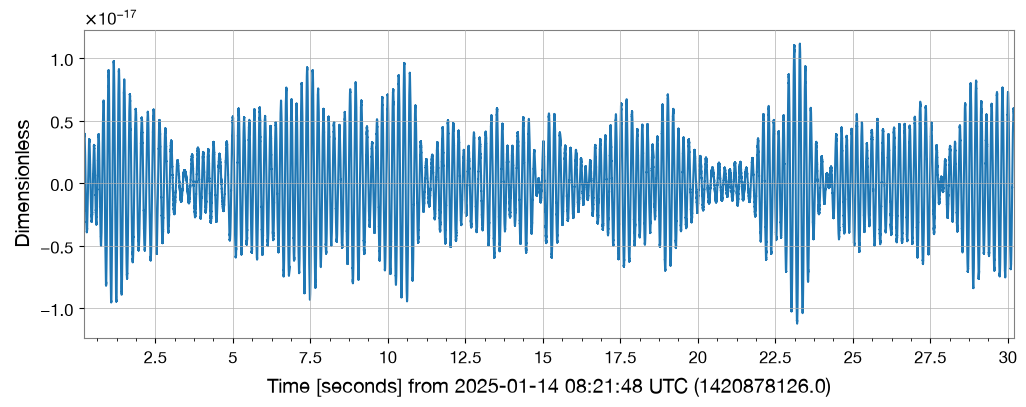

In [6]:
H1_analysis_data.plot()
plt.show()

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


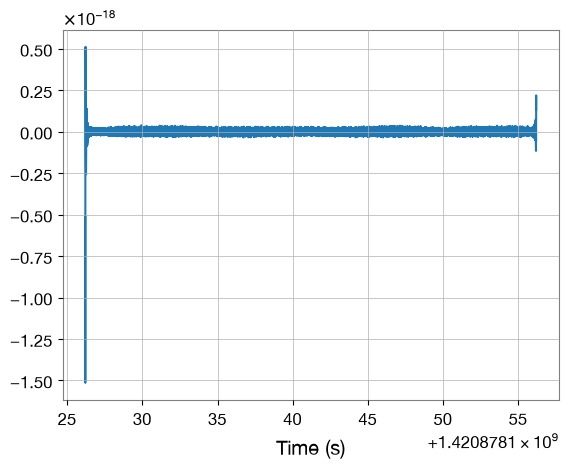

In [7]:
# Remove the low-frequency content and downsample the data to 2048Hz
from pycbc.filter import resample_to_delta_t, highpass

strain = H1_analysis_data.to_pycbc()
strain = highpass(strain, 15.0)
strain = resample_to_delta_t(strain, 1.0/2048)

plt.plot(strain.sample_times, strain)
plt.xlabel('Time (s)')
plt.show()  #after applying filter we get peaks at edges

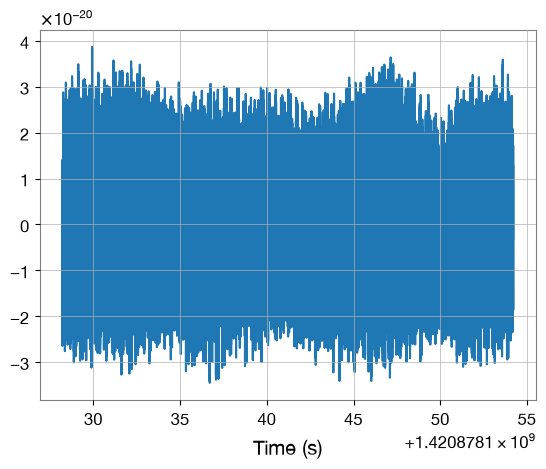

In [8]:
# We remove 2-seconds of data from the edges
conditioned = strain.crop(2, 2)

plt.plot(conditioned.sample_times, conditioned)
plt.xlabel('Time (s)')
plt.show()

In [9]:
from pycbc.psd import interpolate, inverse_spectrum_truncation

# Compute the PSD using 4-second segments
psd = conditioned.psd(4)
# Interpolate the PSD to match the data's frequency resolution
psd = interpolate(psd, conditioned.delta_f)
# Truncate to limit the filter length and remove unwanted low-frequency noise
psd = inverse_spectrum_truncation(psd, int(4 * conditioned.sample_rate), low_frequency_cutoff=15)

lal.MSUN_SI != Msun


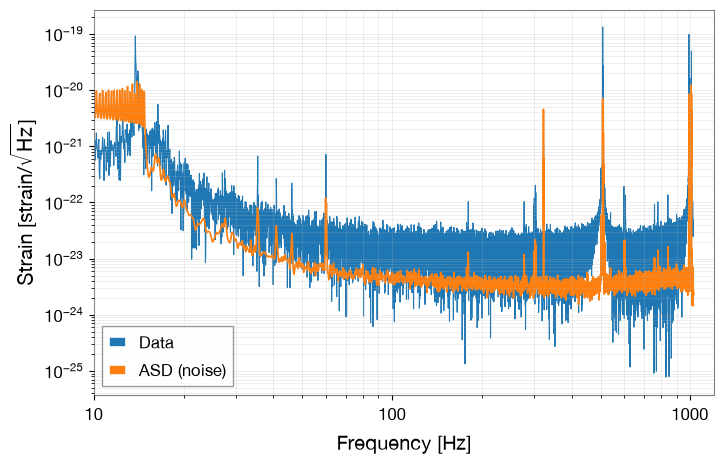

In [10]:
strain_fd = conditioned.to_frequencyseries()

plt.figure(figsize=(8, 5))
plt.loglog(strain_fd.sample_frequencies, abs(strain_fd), lw=0.8, label='Data')
plt.loglog(psd.sample_frequencies, psd**0.5, lw=1.2, label='ASD (noise)')
plt.xlim(10, 1200)
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Strain [strain/$\sqrt{\mathrm{Hz}}$]')
plt.legend()
plt.grid(which='both', alpha=0.3)

In [11]:
# Generate a gravitational waveform for a binary black hole merger
from pycbc.waveform import get_td_waveform

hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=36,
                         mass2=36,
                         delta_t=conditioned.delta_t,
                         f_lower=20)

# Resize to match the data
hp.resize(len(conditioned))

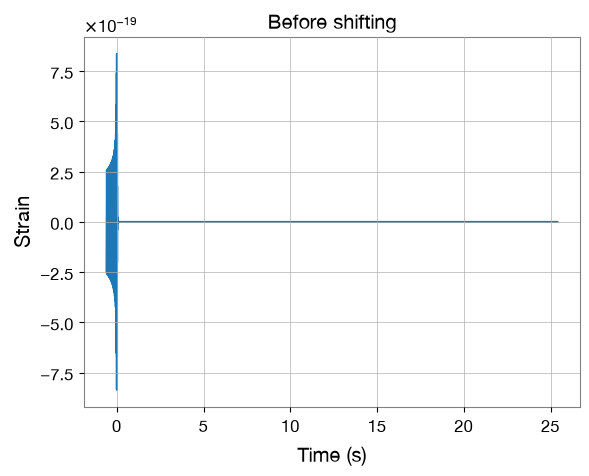

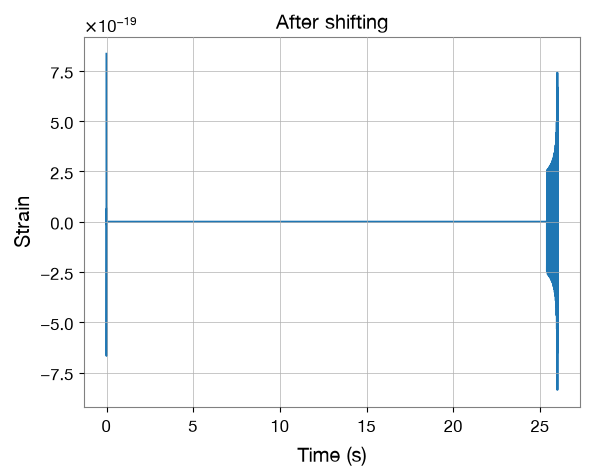

In [12]:
# Let's plot the signal before and after shifting

plt.figure()
plt.title('Before shifting')
plt.plot(hp.sample_times, hp)
plt.xlabel('Time (s)')
plt.ylabel('Strain')

template = hp.cyclic_time_shift(hp.start_time)

plt.figure()
plt.title('After shifting')
plt.plot(template.sample_times, template)
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.show()

In [13]:
from pycbc.filter import matched_filter

# Compute the SNR time series
snr = matched_filter(template, conditioned, psd=psd, low_frequency_cutoff=20)
# Trim to remove corrupted edges
snr = snr.crop(8, 4)

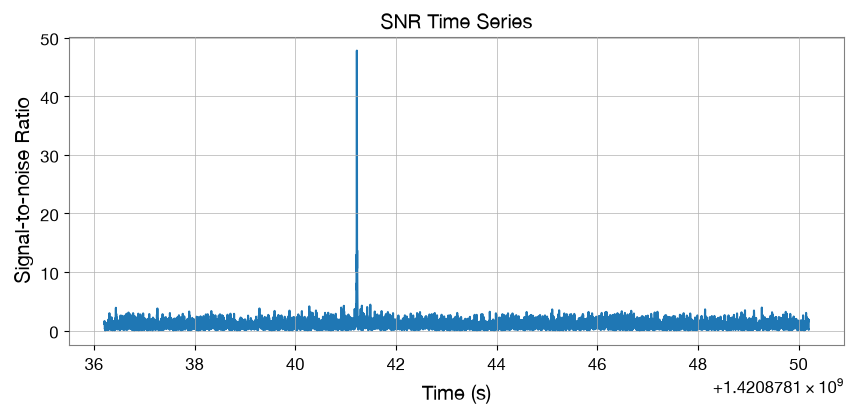

In [14]:
plt.figure(figsize=[10, 4])
plt.plot(snr.sample_times, abs(snr))
plt.ylabel('Signal-to-noise Ratio')
plt.xlabel('Time (s)')
plt.title('SNR Time Series')
plt.show()

In [15]:
peak = abs(snr).numpy().argmax()
snr_peak = snr[peak]
time = snr.sample_times[peak]

print("We found a signal at {}s with SNR {}".format(time, abs(snr_peak)))

We found a signal at 1420878141.220459s with SNR 47.77209816923527


In [16]:
#We next align the signal to the data with respect to time and phase

from pycbc.filter import sigma

# Align the waveform to the detected signal peak
dt = time - conditioned.start_time
aligned = template.cyclic_time_shift(dt)
# Normalize the template to SNR = 1
aligned /= sigma(aligned, psd=psd, low_frequency_cutoff=20)
# Scale by the detected SNR
aligned = (aligned.to_frequencyseries() * snr_peak).to_timeseries()
aligned.start_time = conditioned.start_time

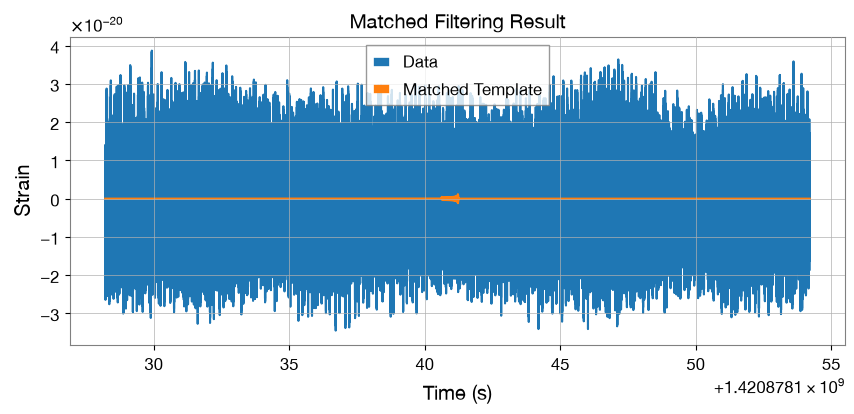

In [17]:
plt.figure(figsize=[10, 4])
plt.plot(conditioned.sample_times, conditioned, label="Data")
plt.plot(aligned.sample_times, aligned, label="Matched Template")
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.legend()
plt.title('Matched Filtering Result')
plt.show()

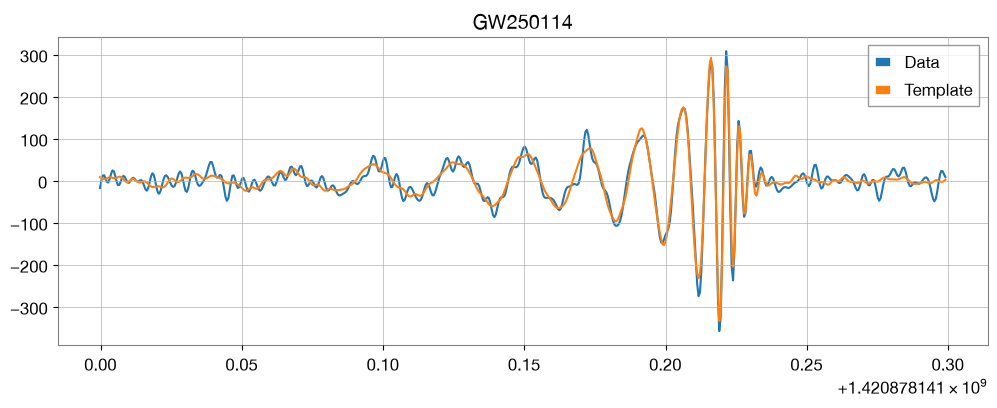

In [18]:
# We whiten the data to get a clear view of the signal strain
white_data = (conditioned.to_frequencyseries() / psd**0.5).to_timeseries()
white_template = (aligned.to_frequencyseries() / psd**0.5).to_timeseries()

white_data = white_data.highpass_fir(30., 512).lowpass_fir(300, 512)
white_template = white_template.highpass_fir(30, 512).lowpass_fir(300, 512)

# Select the time around the merger
white_data = white_data.time_slice(time_of_event-.2, time_of_event+.1)
white_template = white_template.time_slice(time_of_event-.2, time_of_event+.1)

plt.figure(figsize=[12, 4])
plt.plot(white_data.sample_times, white_data, label="Data")
plt.plot(white_template.sample_times, white_template, label="Template")
plt.title('GW250114')
plt.legend()
plt.show()

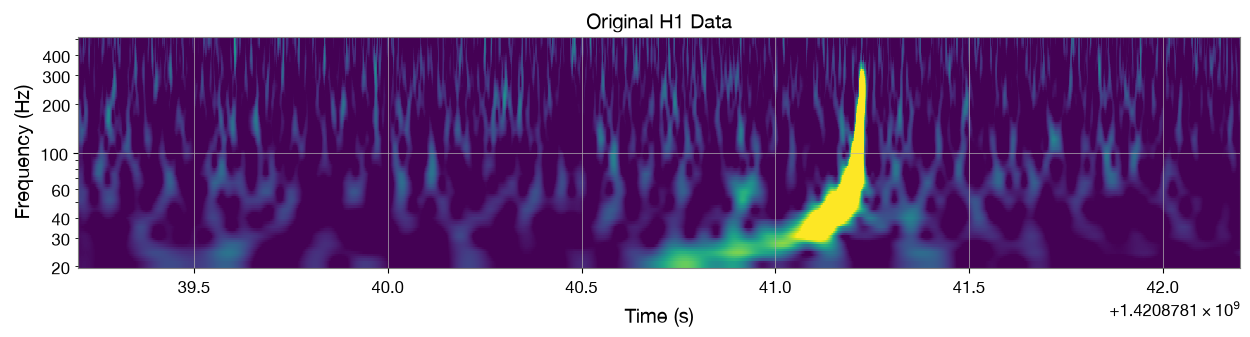

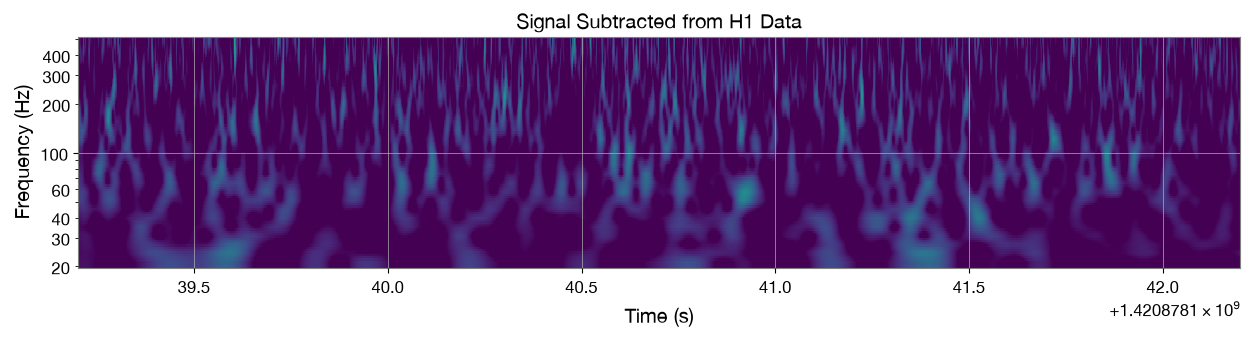

In [19]:
# to see after substraction if signal goes away

subtracted = conditioned - aligned

# Plot the original data and the subtracted signal data

for data, title in [(conditioned, 'Original H1 Data'),
                    (subtracted, 'Signal Subtracted from H1 Data')]:

    t, f, p = data.whiten(4, 4).qtransform(.001, logfsteps=100, qrange=(8, 8), frange=(20, 512))
    plt.figure(figsize=[15, 3])
    plt.title(title)
    plt.pcolormesh(t, f, p**0.5, vmin=1, vmax=6, shading='auto')
    plt.yscale('log')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.xlim(time_of_event - 2, time_of_event + 1)
    plt.show()